# Model Evaluation

This notebook evaluates machine learning models used for predicting employee attrition in the healthcare sector.

Evaluation metrics include:
- Confusion Matrix
- Precision
- Recall
- F1-score
- ROC Curve
- ROC-AUC Score

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
import pandas as pd

employee_df = pd.read_csv('../data/watson_healthcare.csv')

attr_dictionary = {
    'Yes': 1,
    'No': 0
}

employee_df['AttritionNum'] = employee_df['Attrition'].map(attr_dictionary)

employee_df = employee_df.drop(['Attrition','EmployeeID'], axis=1)

column_names = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'Over18',
    'OverTime'
]

int_cols = employee_df.drop(column_names, axis=1)

obj_columns = employee_df.filter(column_names, axis=1)

obj_columns_one_hot = pd.get_dummies(
    obj_columns,
    drop_first=True
)

employee_df_new = pd.concat(
    [int_cols, obj_columns_one_hot],
    axis=1
)

In [14]:
X =  employee_df_new.drop(['AttritionNum'], axis=1)
Y = employee_df_new.filter(['AttritionNum'], axis=1)

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.25,random_state=4
)

In [15]:
RF_clf = RandomForestClassifier()

RF_clf.fit(X_train,Y_train)

test_pred_RF = RF_clf.predict(X_test)

c:\Users\soora\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


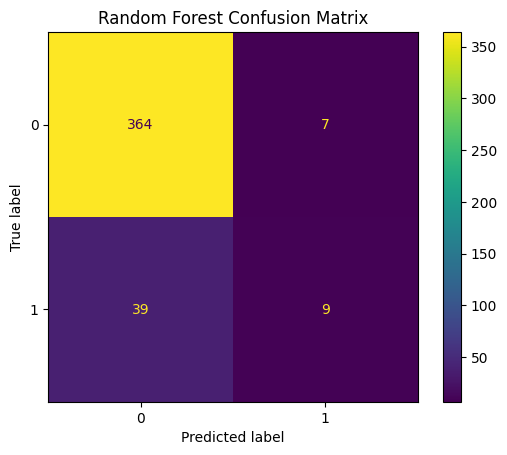

In [16]:
cm = confusion_matrix(Y_test, test_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [17]:
print(classification_report(Y_test, test_pred_RF))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       371
           1       0.56      0.19      0.28        48

    accuracy                           0.89       419
   macro avg       0.73      0.58      0.61       419
weighted avg       0.86      0.89      0.87       419



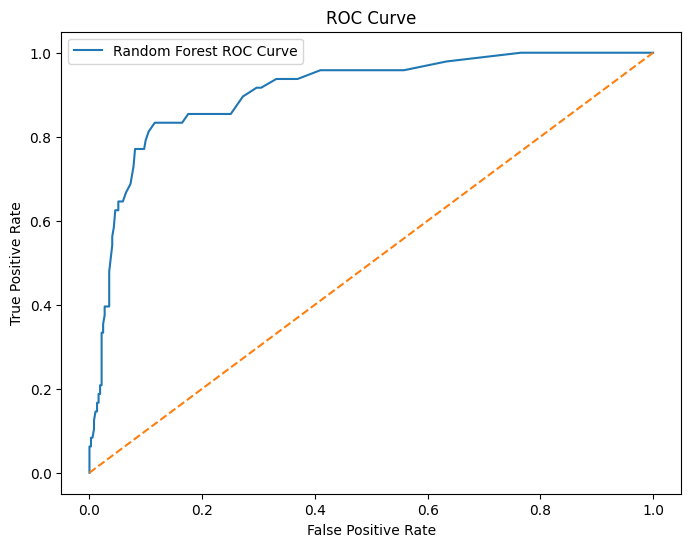

In [18]:
y_prob_RF = RF_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, y_prob_RF)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Random Forest ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [19]:
auc_score = roc_auc_score(Y_test, y_prob_RF)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9064746181491463


## Observation

The Random Forest model achieved strong classification performance with a high ROC-AUC score, indicating good ability to distinguish between employees likely to leave and employees likely to stay.

The confusion matrix also shows that the model correctly classified most employee attrition cases.

# XGBoost Model

In [21]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, Y_train)

xgb_pred = xgb_model.predict(X_test)

In [22]:
print(classification_report(Y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       371
           1       0.60      0.38      0.46        48

    accuracy                           0.90       419
   macro avg       0.76      0.67      0.70       419
weighted avg       0.89      0.90      0.89       419



In [23]:
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(Y_test, xgb_prob)

print("XGBoost ROC-AUC Score:", xgb_auc)

XGBoost ROC-AUC Score: 0.9282345013477089


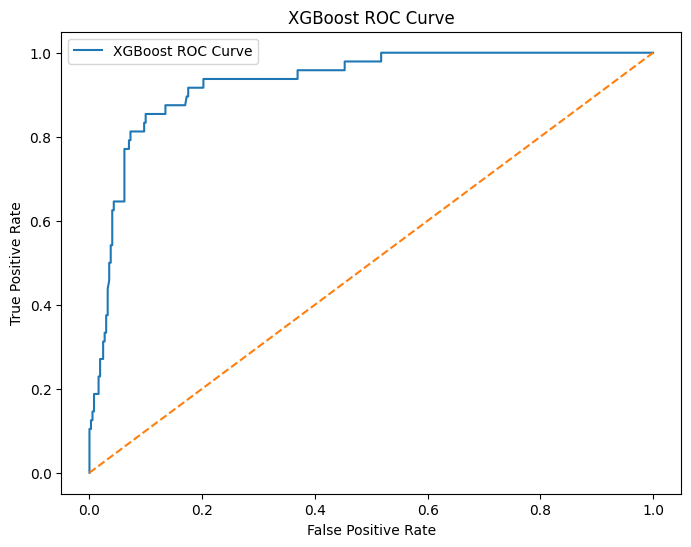

In [24]:
fpr_xgb, tpr_xgb, thresholds = roc_curve(Y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_xgb, tpr_xgb, label='XGBoost ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('XGBoost ROC Curve')

plt.legend()

plt.show()

In [26]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

In [27]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

In [28]:
grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [29]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [30]:
print("Best ROC-AUC Score:")
print(grid_search.best_score_)

Best ROC-AUC Score:
0.9362824053858612


In [31]:
import joblib

joblib.dump(xgb_model, '../models/best_model.pkl')

['../models/best_model.pkl']